# Probability and Statistics (MT-2005) — Semester Project
## Online News Popularity  Linear Regression & Classification
**FAST NUCES Islamabad | Spring 2026**

#### **1. Introduction & Motivation**

In the digital media landscape, predicting article popularity before or shortly after publication offers significant value to publishers, marketers, and content creators. Understanding which features drive user engagement can help organizations optimize content strategy, improve audience targeting, and increase reach.

This project uses the UCI Online News Popularity Dataset to explore how article characteristics, such as length, sentiment, topic category, and publishing time, influence the number of social media shares an article receives. We apply linear regression for continuous prediction, logistic regression for binary classification, and statistical hypothesis testing to draw actionable insights.

***Target Variable:***

* shares — the number of times an article was shared on social media, used as a proxy for popularity.

## 1. Imports & Setup

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, confusion_matrix, classification_report
)
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, chi2_contingency, mannwhitneyu

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('All libraries loaded successfully!!')

All libraries loaded successfully!!


## 2. Data Loading & Initial Inspection

In [38]:
df = pd.read_csv('/content/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()
print(f'Shape: {df.shape}')
df.head()

Shape: (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [39]:
print('Column dtypes:')
print(df.dtypes.value_counts())
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

print(f'Column Names: {df.columns}')

Column dtypes:
float64    59
object      1
int64       1
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0
Column Names: Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       

* No missing values found in data set.
* No duplicated rows.

In [40]:
print('Basic statistics of target variable (shares):')
df['shares'].describe()

Basic statistics of target variable (shares):


,shares
count,39644.000000
mean,3395.380184
std,11626.950749
min,1.000000
25%,946.000000
50%,1400.000000
75%,2800.000000
max,843300.000000


**Target Variable Summary**

The target is extremely right-skewed (mean >> median), with a maximum of 843, 300 shares. This motivates log-transformation for regression.

 **Attribute Information:**

     0. url:                           URL of the article
     1. timedelta:                     Days between the article publication and
                                       the dataset acquisition
     2. n_tokens_title:                Number of words in the title
     3. n_tokens_content:              Number of words in the content
     4. n_unique_tokens:               Rate of unique words in the content
     5. n_non_stop_words:              Rate of non-stop words in the content
     6. n_non_stop_unique_tokens:      Rate of unique non-stop words in the
                                       content
     7. num_hrefs:                     Number of links
     8. num_self_hrefs:                Number of links to other articles
                                       published by Mashable
     9. num_imgs:                      Number of images
    10. num_videos:                    Number of videos
    11. average_token_length:          Average length of the words in the
                                       content
    12. num_keywords:                  Number of keywords in the metadata
    13. data_channel_is_lifestyle:     Is data channel 'Lifestyle'?
    14. data_channel_is_entertainment: Is data channel 'Entertainment'?
    15. data_channel_is_bus:           Is data channel 'Business'?
    16. data_channel_is_socmed:        Is data channel 'Social Media'?
    17. data_channel_is_tech:          Is data channel 'Tech'?
    18. data_channel_is_world:         Is data channel 'World'?
    19. kw_min_min:                    Worst keyword (min. shares)
    20. kw_max_min:                    Worst keyword (max. shares)
    21. kw_avg_min:                    Worst keyword (avg. shares)
    22. kw_min_max:                    Best keyword (min. shares)
    23. kw_max_max:                    Best keyword (max. shares)
    24. kw_avg_max:                    Best keyword (avg. shares)
    25. kw_min_avg:                    Avg. keyword (min. shares)
    26. kw_max_avg:                    Avg. keyword (max. shares)
    27. kw_avg_avg:                    Avg. keyword (avg. shares)
    28. self_reference_min_shares:     Min. shares of referenced articles in
                                       Mashable
    29. self_reference_max_shares:     Max. shares of referenced articles in
                                       Mashable
    30. self_reference_avg_sharess:    Avg. shares of referenced articles in
                                       Mashable
    31. weekday_is_monday:             Was the article published on a Monday?
    32. weekday_is_tuesday:            Was the article published on a Tuesday?
    33. weekday_is_wednesday:          Was the article published on a Wednesday?
    34. weekday_is_thursday:           Was the article published on a Thursday?
    35. weekday_is_friday:             Was the article published on a Friday?
    36. weekday_is_saturday:           Was the article published on a Saturday?
    37. weekday_is_sunday:             Was the article published on a Sunday?
    38. is_weekend:                    Was the article published on the weekend?
    39. LDA_00:                        Closeness to LDA topic 0
    40. LDA_01:                        Closeness to LDA topic 1
    41. LDA_02:                        Closeness to LDA topic 2
    42. LDA_03:                        Closeness to LDA topic 3
    43. LDA_04:                        Closeness to LDA topic 4
    44. global_subjectivity:           Text subjectivity
    45. global_sentiment_polarity:     Text sentiment polarity
    46. global_rate_positive_words:    Rate of positive words in the content
    47. global_rate_negative_words:    Rate of negative words in the content
    48. rate_positive_words:           Rate of positive words among non-neutral
                                       tokens
    49. rate_negative_words:           Rate of negative words among non-neutral
                                       tokens
    50. avg_positive_polarity:         Avg. polarity of positive words
    51. min_positive_polarity:         Min. polarity of positive words
    52. max_positive_polarity:         Max. polarity of positive words
    53. avg_negative_polarity:         Avg. polarity of negative  words
    54. min_negative_polarity:         Min. polarity of negative  words
    55. max_negative_polarity:         Max. polarity of negative  words
    56. title_subjectivity:            Title subjectivity
    57. title_sentiment_polarity:      Title polarity
    58. abs_title_subjectivity:        Absolute subjectivity level
    59. abs_title_sentiment_polarity:  Absolute polarity level
    60. shares:                        Number of shares (target)

## 3. Data Preprocessing

## Invalid Data Removal

* Removing url and timedelta becuase they are not helpful for prediction.
* Rows with Shares < 0, because in real world, shares can not be negative (no value found)
* Rows with n_unique_tokens > 1 represent data entry errors (the feature is defined as a ratio). Only one row found

In [41]:
df.drop(columns=['url', 'timedelta'], inplace=True)
print(f'After dropping url & timedelta: {df.shape}')

print(f'\nRows with shares <= 0: {(df["shares"] <= 0).sum()}')
df = df[df['shares'] > 0].reset_index(drop=True)

print(f'\nn_unique_tokens > 1: {(df["n_unique_tokens"] > 1).sum()}')
#removing rows having token outside range
df = df[(df['n_unique_tokens'] <= 1) & (df['n_non_stop_unique_tokens'] <= 1)].reset_index(drop=True)
print(f'After filtering token ratios: {df.shape}')

After dropping url & timedelta: (39644, 59)

Rows with shares <= 0: 0

n_unique_tokens > 1: 1
After filtering token ratios: (39643, 59)


## Redundant Feature Removal

Before modeling, we remove features that carry no useful information:

- **Zero-variance features**: columns with the same value in every row contribute nothing to prediction.
- **Highly correlated features**: if two features are correlated above 0.90, they carry nearly identical information. Keeping both inflates the feature space and can cause multicollinearity issues in linear models. We drop one from each redundant pair.

`shares` (the target variable) is excluded from this check as its relationship with features is what the model learns.

In [42]:
#removing those features which have same value in each row they are repittive and of no use in prediction
selector = VarianceThreshold(threshold=0.0)
selector.fit(df.drop(columns=['shares']))
zero_var_cols = df.drop(columns=['shares']).columns[~selector.get_support()].tolist()
print(f'Zero-variance features (redundant): {zero_var_cols}')

# finding perfect correlation pairs
corr_matrix = df.drop(columns=['shares']).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > 0.90]
print(f'\nHighly correlated pairs (>0.90):')
for c1, c2, val in high_corr_pairs:
    print(f'  {c1} <-> {c2}: {val:.3f}')

Zero-variance features (redundant): []

Highly correlated pairs (>0.90):
  n_non_stop_unique_tokens <-> n_unique_tokens: 0.938
  average_token_length <-> n_non_stop_words: 0.944
  kw_avg_min <-> kw_max_min: 0.941


In [43]:
# remving redundant highly correlated features
to_drop_corr = ['n_non_stop_unique_tokens', 'n_non_stop_words', 'kw_max_min']
df.drop(columns=to_drop_corr, inplace=True)
print(f'Dropped: {to_drop_corr}')
print(f'Remaining shape: {df.shape}')

Dropped: ['n_non_stop_unique_tokens', 'n_non_stop_words', 'kw_max_min']
Remaining shape: (39643, 56)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Descriptive Statistics

In [44]:
desc_cols = ['n_tokens_content', 'num_imgs', 'num_videos', 'num_keywords',
             'global_sentiment_polarity', 'shares']
stats_df = df[desc_cols].describe().T
stats_df['skewness'] = df[desc_cols].skew()
stats_df['kurtosis'] = df[desc_cols].kurtosis()
stats_df['median'] = df[desc_cols].median()
stats_df['IQR'] = df[desc_cols].quantile(0.75) - df[desc_cols].quantile(0.25)
stats_df.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,median,IQR
n_tokens_content,39643.0,546.49,471.09,0.00,246.00,409.00,716.00,8474.00,2.95,19.48,409.00,470.00
num_imgs,39643.0,4.54,8.31,0.00,1.00,1.00,4.00,128.00,3.95,24.55,1.00,3.00
num_videos,39643.0,1.25,4.11,0.00,0.00,0.00,1.00,91.00,7.02,74.07,0.00,1.00
num_keywords,39643.0,7.22,1.91,1.00,6.00,7.00,9.00,10.00,-0.15,-0.81,7.00,3.00
global_sentiment_polarity,39643.0,0.12,0.10,-0.39,0.06,0.12,0.18,0.73,0.11,1.51,0.12,0.12
shares,39643.0,3395.32,11627.09,1.00,946.00,1400.00,2800.00,843300.00,33.96,1832.63,1400.00,1854.00


### 4.2 Distribution of Key Variables

Histograms reveal the shape of each variable.  

`**shares**' is heavily right-skewed (most articles get few shares, a few go viral), so we plot it on a log scale. Red dashed = mean, orange dash-dot = median.

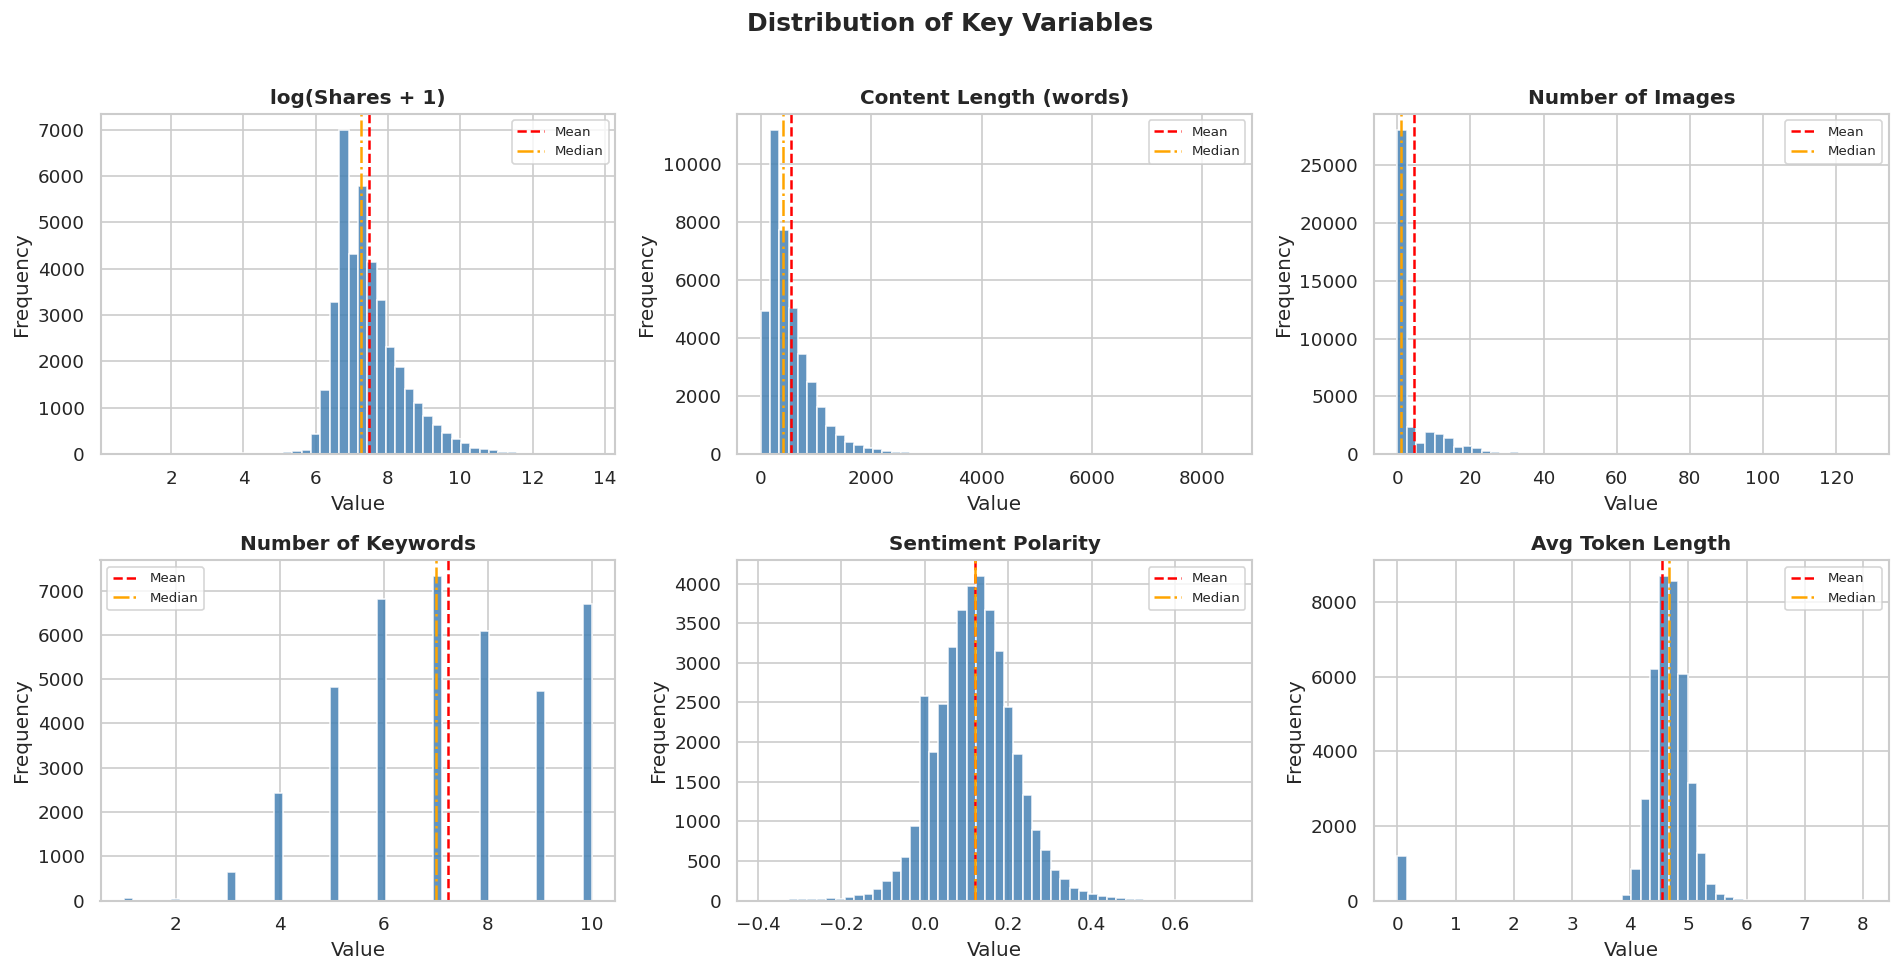

Figure saved.


In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_cols = ['shares', 'n_tokens_content', 'num_imgs', 'num_keywords','global_sentiment_polarity', 'average_token_length']
titles = ['Shares (Target)', 'Content Length (words)', 'Number of Images','Number of Keywords', 'Sentiment Polarity', 'Avg Token Length']

for ax, col, title in zip(axes.flatten(), plot_cols, titles):
    data = df[col]
    if col == 'shares':
        data = np.log1p(data)
        title = 'log(Shares + 1)'
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(data.median(), color='orange', linestyle='-.', linewidth=1.5, label='Median')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

### 4.3 Correlation Heatmap

A heatmap of Pearson correlations among a selected subset of features (plus `shares') helps identify which features move together. Strong inter-feature correlations can signal multicollinearity.

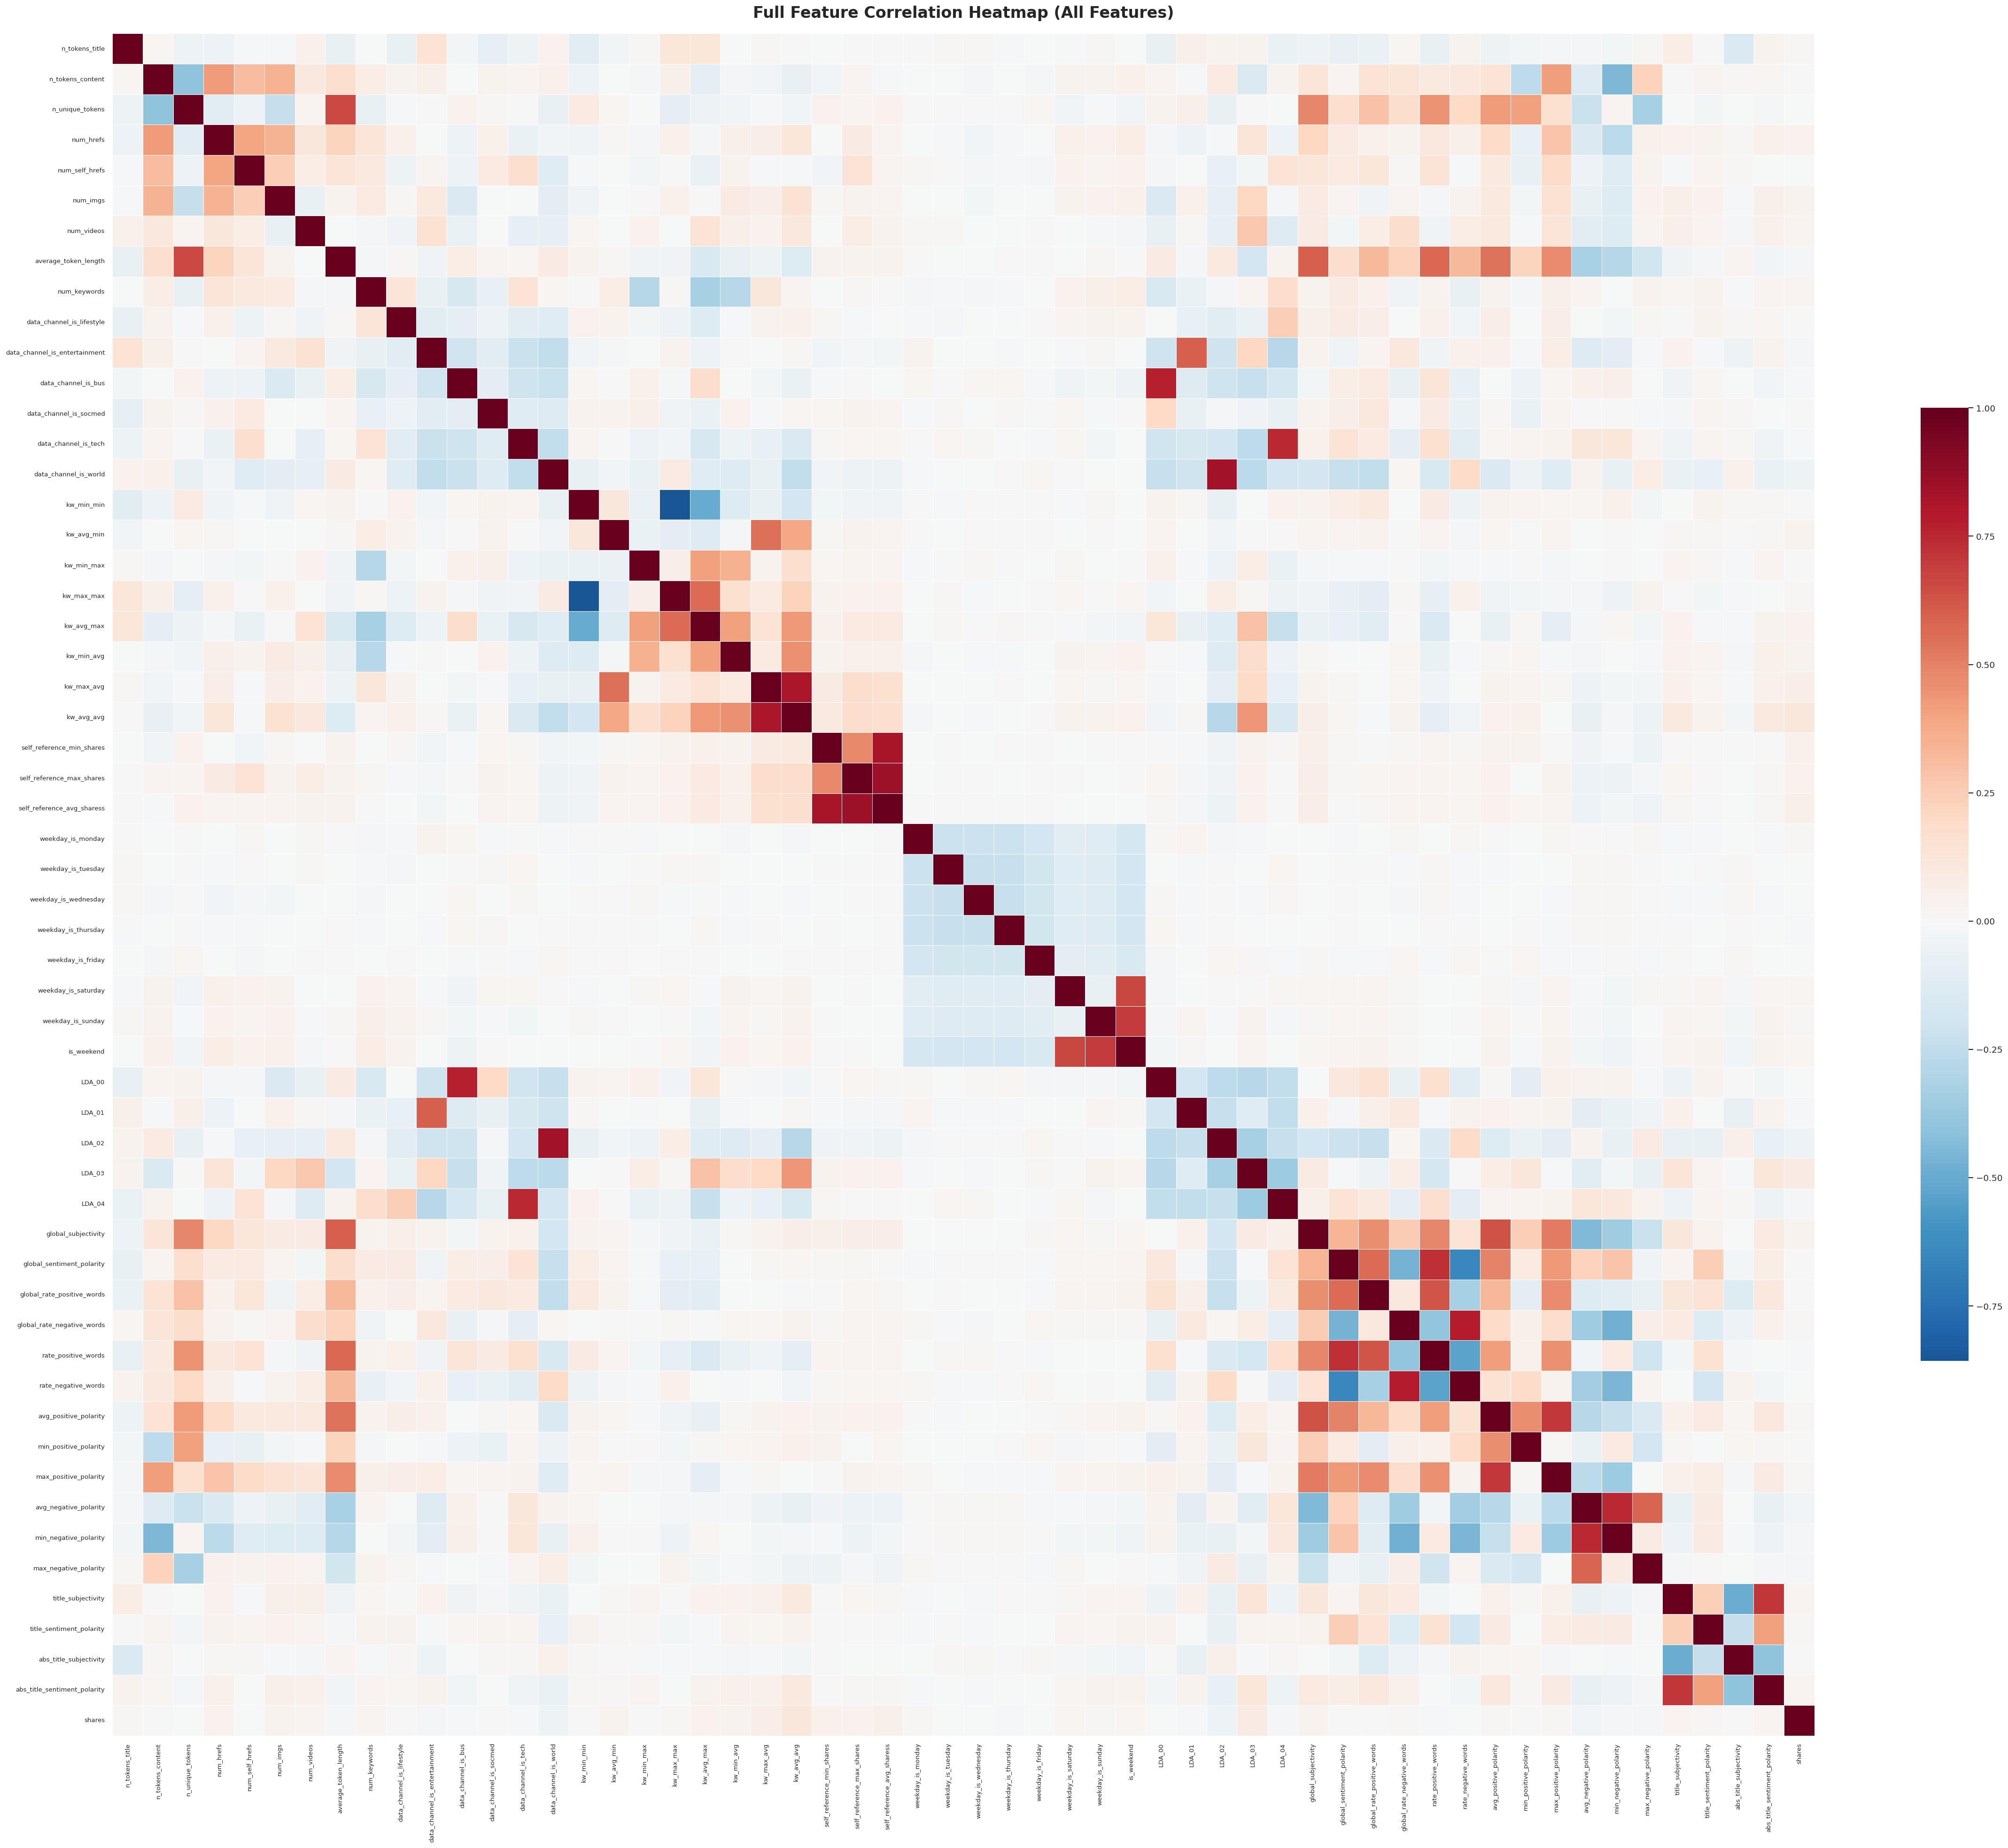

In [46]:
# Full correlation heatmap (all features)
fig, ax = plt.subplots(figsize=(40, 35))
corr_full = df.corr()
sns.heatmap(corr_full, annot=False, cmap='RdBu_r',    # annot=False — too many cells to annotate
            center=0, square=True, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.5})
ax.set_title('Full Feature Correlation Heatmap (All Features)',
             fontsize=20, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('fig_heatmap_all_columns.png', bbox_inches='tight', dpi=150)
plt.show()

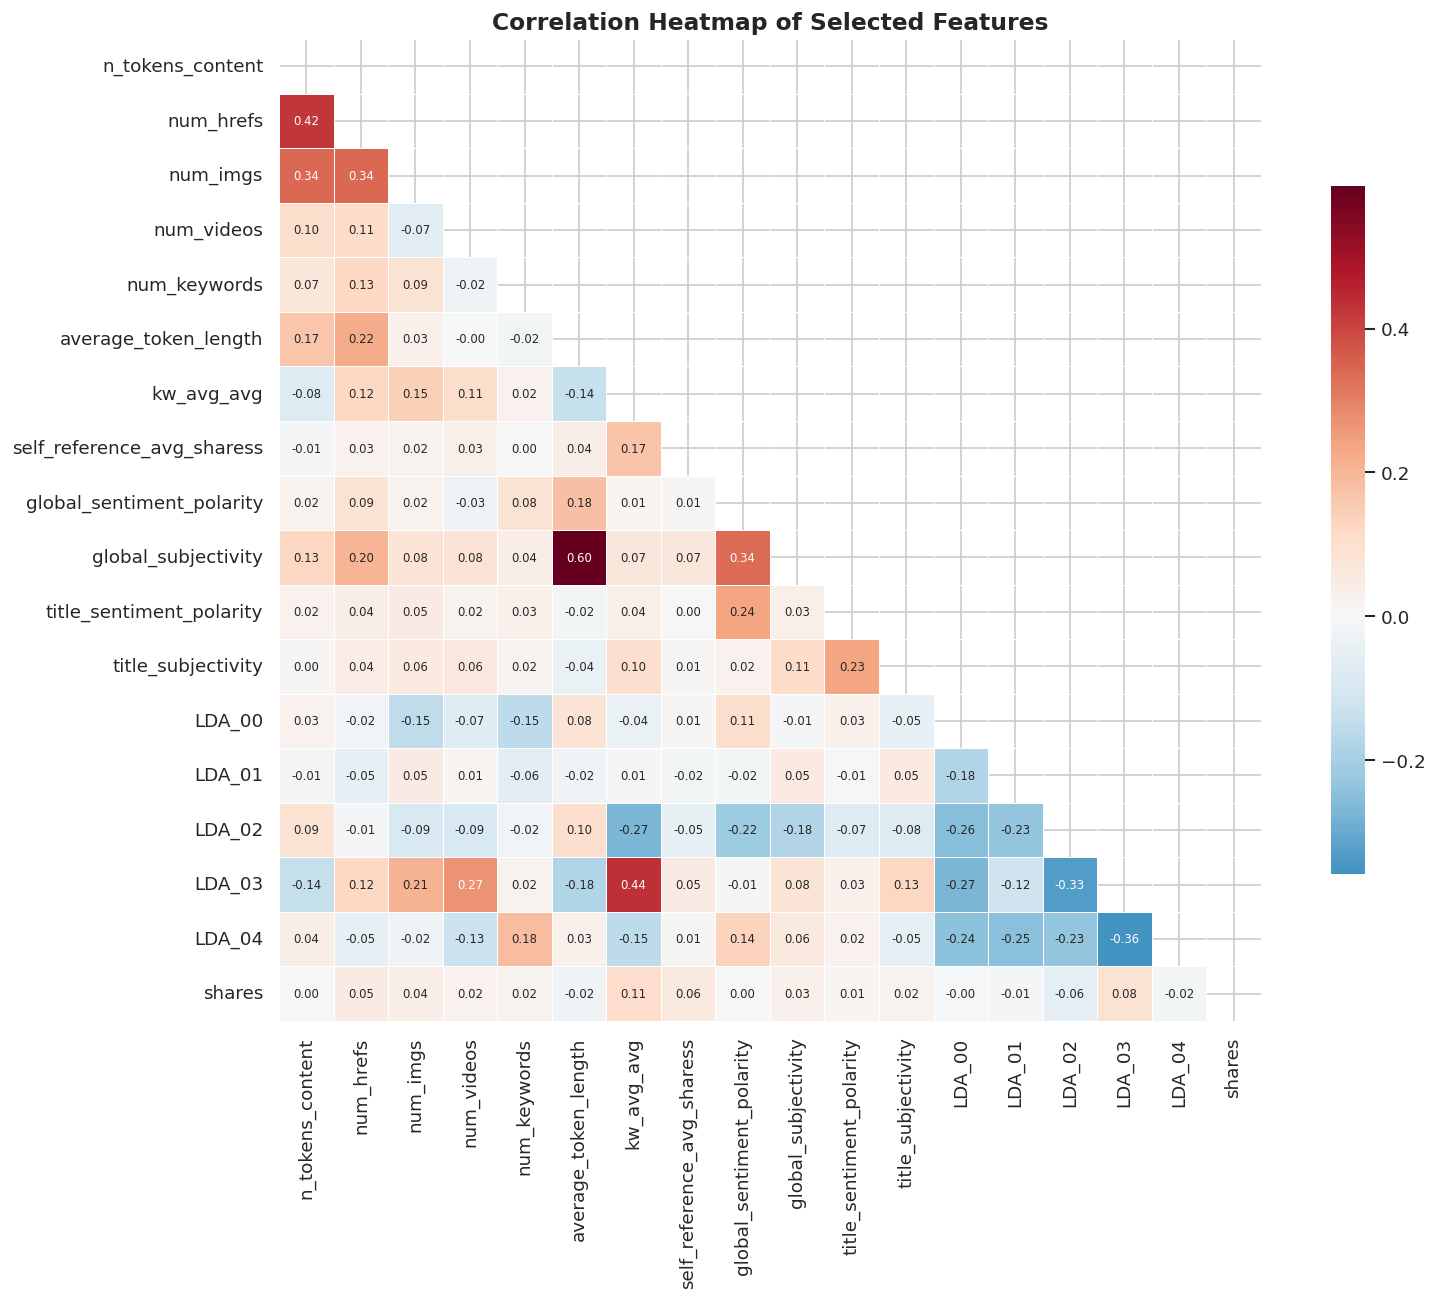

In [47]:
# Select a meaningful subset for heatmap clarity
heatmap_cols = ['n_tokens_content', 'num_hrefs', 'num_imgs', 'num_videos', 'num_keywords','average_token_length', 'kw_avg_avg', 'self_reference_avg_sharess',
'global_sentiment_polarity', 'global_subjectivity','title_sentiment_polarity', 'title_subjectivity','LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'shares'
]
heatmap_cols = [c for c in heatmap_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap of Selected Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight')
plt.show()

### 4.4 Shares vs. Selected Features

We automatically select the 7 features with the highest absolute Pearson correlation with log(shares) and plot each against the target. The red line is the OLS trend line.

Even the strongest correlations are modest, confirming that no single feature dominates consistent with what we observed in the heatmap.

Top 7 features by correlation with log(shares):
kw_avg_avg               0.2218
LDA_02                   0.1651
data_channel_is_world    0.1517
LDA_03                   0.1261
is_weekend               0.1144
kw_max_avg               0.1094
kw_min_avg               0.1088
dtype: float64


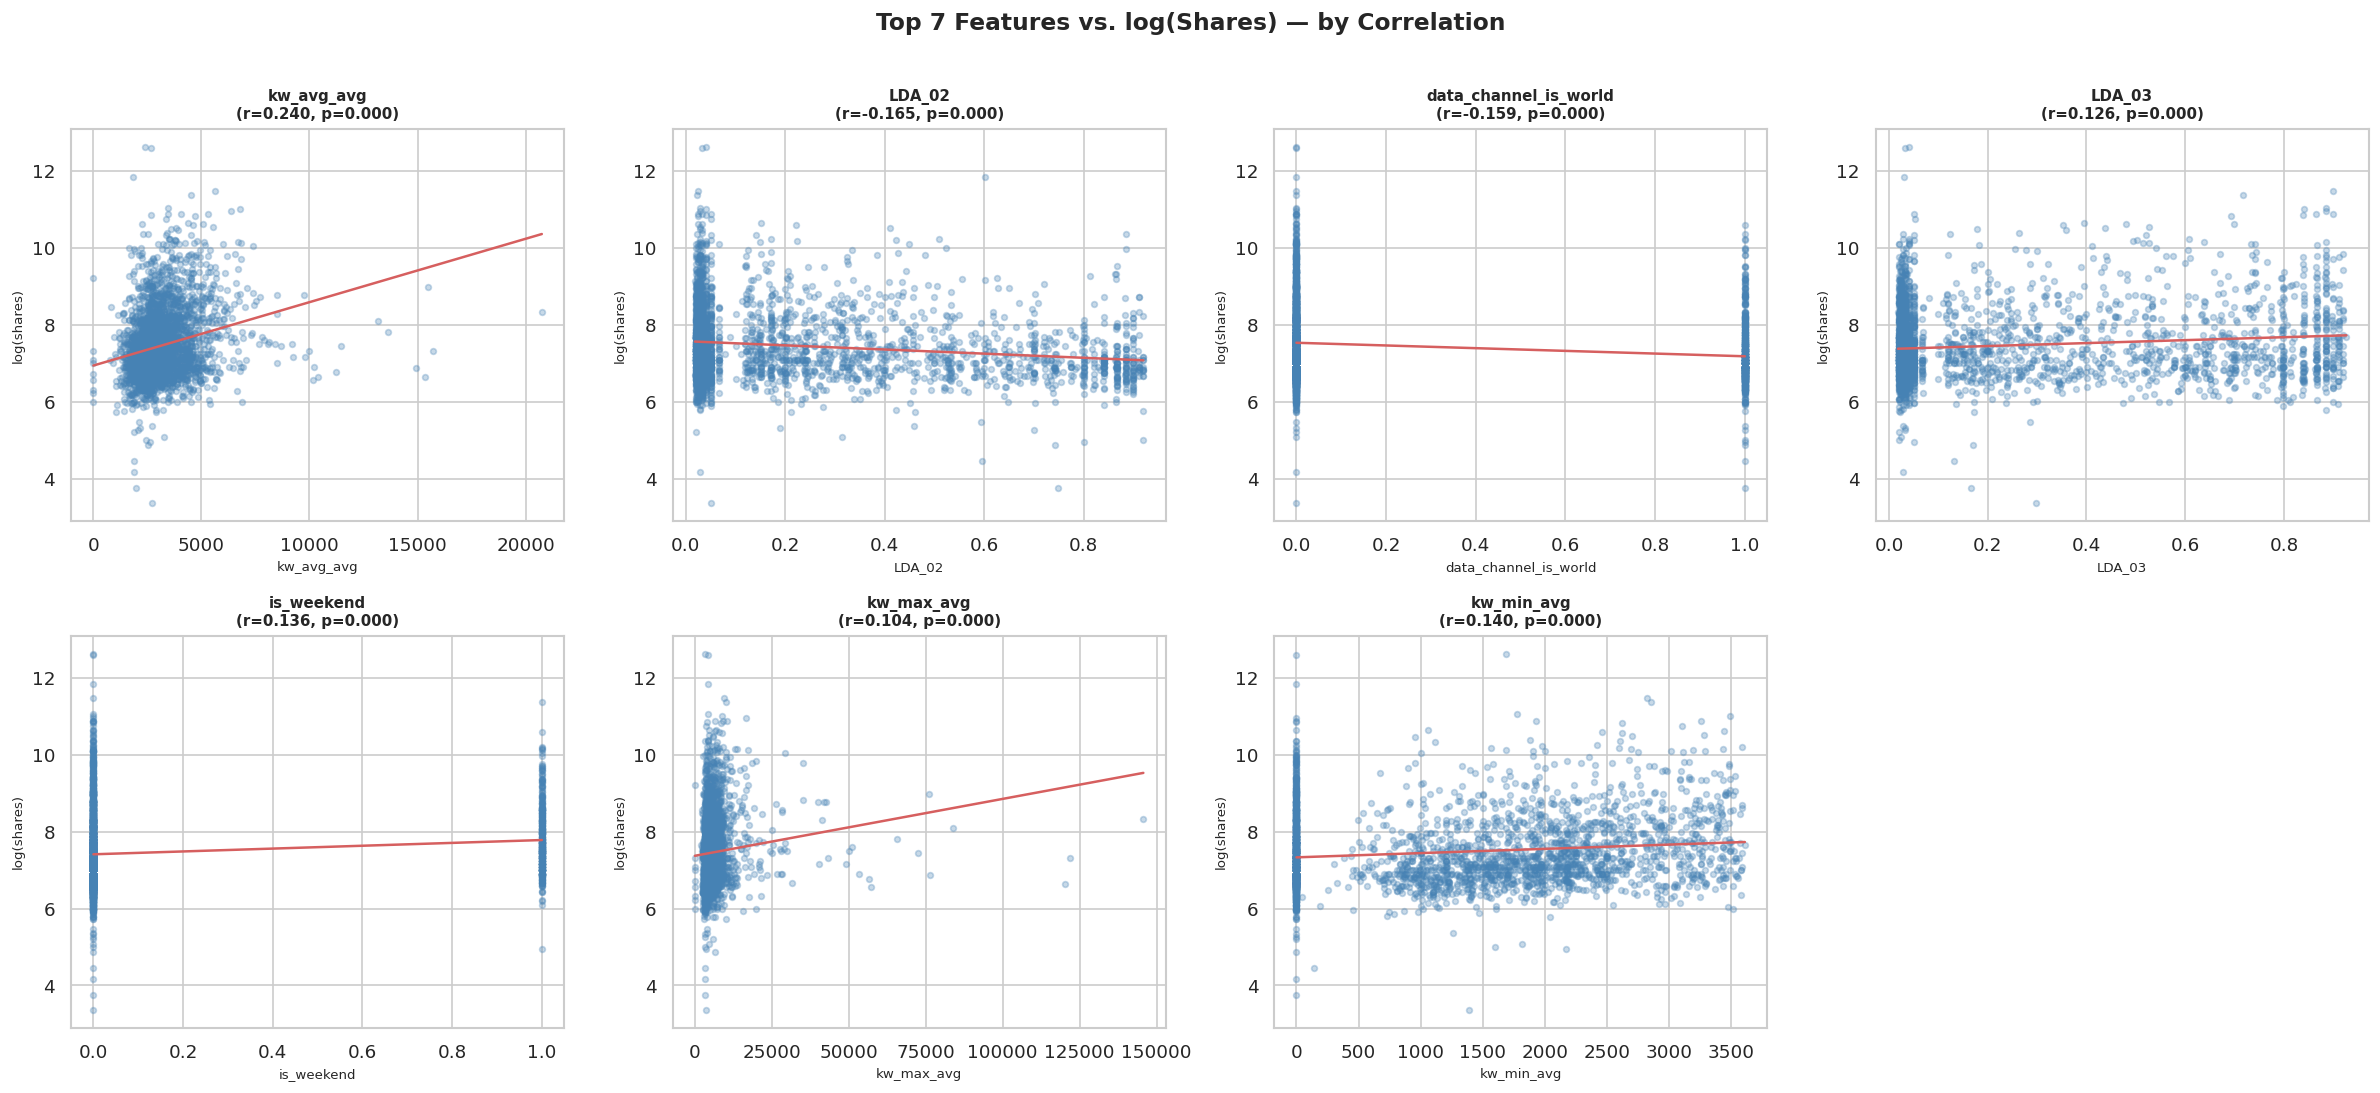

In [48]:
# Select top 7 features most correlated with log(shares)
log_shares = np.log1p(df['shares'])
correlations = df.drop(columns=['shares']).corrwith(log_shares).abs()
scatter_feats = correlations.sort_values(ascending=False).head(7).index.tolist()
print('Top 7 features by correlation with log(shares):')
print(correlations[scatter_feats].round(4))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))  # 2 rows x 4 cols = 8 slots for 7 plots

for ax, feat in zip(axes.flatten(), scatter_feats):
    sample = df.sample(3000, random_state=42)
    ax.scatter(sample[feat], np.log1p(sample['shares']),
               alpha=0.3, s=12, color='steelblue')
    z  = np.polyfit(sample[feat].fillna(0), np.log1p(sample['shares']), 1)
    xs = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'r-', linewidth=1.5)
    r, pval = pearsonr(sample[feat].fillna(0), np.log1p(sample['shares']))
    ax.set_title(f'{feat}\n(r={r:.3f}, p={pval:.3f})', fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('log(shares)', fontsize=8)

axes.flatten()[-1].set_visible(False)  # hide the empty 8th slot

plt.suptitle('Top 7 Features vs. log(Shares) — by Correlation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_scatter.png', bbox_inches='tight')
plt.show()

### 4.5 Channel Analysis & Day-of-Week Patterns

We compare median shares across content channels (e.g. Tech, World, Business) and days of the week. Median is used instead of mean to reduce the influence of viral outliers.

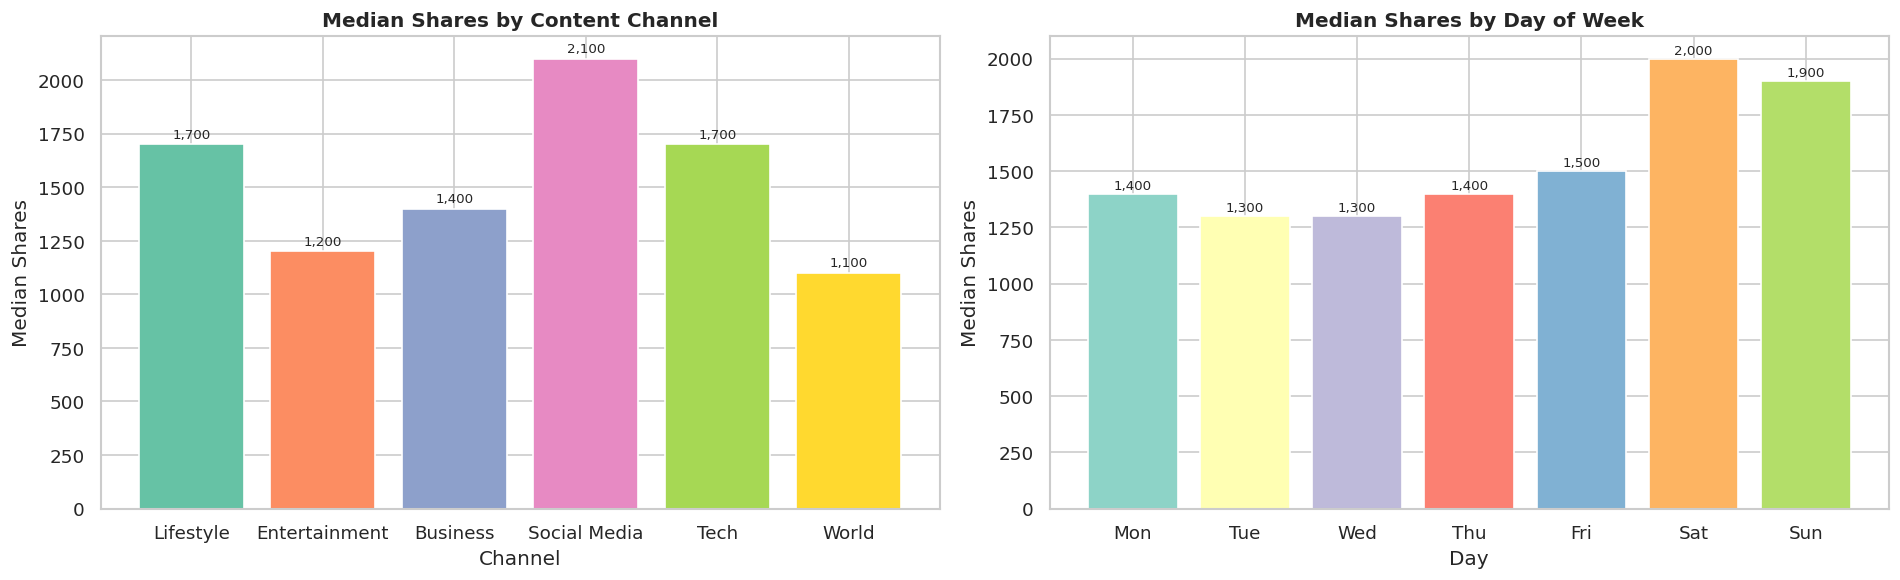

In [49]:
channel_cols   = ['data_channel_is_lifestyle', 'data_channel_is_entertainment',
                  'data_channel_is_bus', 'data_channel_is_socmed',
                  'data_channel_is_tech', 'data_channel_is_world']
channel_labels = ['Lifestyle', 'Entertainment', 'Business', 'Social Media', 'Tech', 'World']

day_cols   = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
              'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday']
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

channel_medians = [df[df[c]==1]['shares'].median() if c in df.columns else 0
                   for c in channel_cols]
bars = axes[0].bar(channel_labels, channel_medians, color=sns.color_palette('Set2', 6))
axes[0].set_title('Median Shares by Content Channel', fontweight='bold')
axes[0].set_ylabel('Median Shares')
axes[0].set_xlabel('Channel')
for bar, val in zip(bars, channel_medians):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(val):,}', ha='center', fontsize=8)

day_medians = [df[df[c]==1]['shares'].median() if c in df.columns else 0
               for c in day_cols]
bars2 = axes[1].bar(day_labels, day_medians, color=sns.color_palette('Set3', 7))
axes[1].set_title('Median Shares by Day of Week', fontweight='bold')
axes[1].set_ylabel('Median Shares')
axes[1].set_xlabel('Day')
for bar, val in zip(bars2, day_medians):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{int(val):,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_channel_day.png', bbox_inches='tight')
plt.show()

## 5. Normalization & Feature Engineering

'**shares**' is heavily right-skewed, so we apply a log(1 + x) transformation to create a more normally distributed regression target. We then define the feature matrix, create a binary classification target (high vs. low shares using the median as threshold), split into train/test sets, and standardize features using z-score normalization. Fitting the scaler on training data only prevents data leakage into the test set.

In [50]:
# Log-transform the target to reduce skewness
df['log_shares'] = np.log1p(df['shares'])

# Feature matrix (exclude both target columns)
X     = df.drop(columns=['shares', 'log_shares'])
y_reg = df['log_shares']   # regression target

# Binary classification target: 1 = high shares (>= median), 0 = low
median_shares     = df['shares'].median()
df['share_class'] = (df['shares'] >= median_shares).astype(int)
y_clf = df['share_class']
print(f'Median shares threshold: {median_shares}')
print(f'Class distribution:\n{y_clf.value_counts()}')

# Train/test split (80/20)
X_train, X_test, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE)
_, _, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE)

# Standardize features (fit on train only to avoid data leakage)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'\nTrain: {X_train_s.shape}, Test: {X_test_s.shape}')

Median shares threshold: 1400.0
Class distribution:
share_class
1    21153
0    18490
Name: count, dtype: int64

Train: (31714, 55), Test: (7929, 55)


## 6. Linear Regression Model

We train a standard Ordinary Least Squares (OLS) linear regression model on the standardized features to predict log(shares). Performance is evaluated using RMSE, MAE, and R² on both train and test sets. Similar train and test scores indicate the model is not overfitting.

In [51]:
lr = LinearRegression()
lr.fit(X_train_s, y_train_r)
y_pred_train_r = lr.predict(X_train_s)
y_pred_test_r  = lr.predict(X_test_s)

print("Linear Regression Performance")
for split, y_true, y_pred in [('Train', y_train_r, y_pred_train_r), ('Test',  y_test_r,  y_pred_test_r)]:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{split}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}')

Linear Regression Performance
Train: RMSE=0.8703, MAE=0.6430, R²=0.1253
Test: RMSE=0.8648, MAE=0.6434, R²=0.1278


### 6.1 Mean Baseline vs. Fitted Model

A mean baseline predicts the training mean for every sample regardless of features, i,e, the simplest possible model. If a fitted model cannot beat this, it adds no value.

We compare both models on RMSE, MAE, and R² to determine which approach is more
suitable for this dataset.

**Results:**
- Linear Regression reduces RMSE by ~6.6% over the baseline
- R² improves from ≈ 0 to 0.1278, meaning the model explains 13% of variance in log(shares)
- Both RMSE and MAE improve, confirming the fitted model is consistently better

**Conclusion:** The linear regression meaningfully outperforms the mean baseline across all three metrics. However, the modest R² = 0.1278 suggests that while the fitted model is the better choice, article virality has substantial unexplained variance, likely driven by non-linear and social factors that a linear model cannot capture.

In [52]:
baseline_pred = np.full(len(y_test_r), y_train_r.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test_r, baseline_pred))
baseline_mae  = mean_absolute_error(y_test_r, baseline_pred)
baseline_r2   = r2_score(y_test_r, baseline_pred)

model_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_test_r))
model_mae  = mean_absolute_error(y_test_r, y_pred_test_r)
model_r2   = r2_score(y_test_r, y_pred_test_r)

comparison = pd.DataFrame({
    'Model': ['Mean Baseline', 'Linear Regression'],
    'RMSE':  [round(baseline_rmse, 4), round(model_rmse, 4)],
    'MAE':   [round(baseline_mae,  4), round(model_mae,  4)],
    'R²':    [round(baseline_r2,   4), round(model_r2,   4)]
})
print(comparison.to_string(index=False))

improvement_rmse = (baseline_rmse - model_rmse) / baseline_rmse * 100
print(f'\nRMSE improvement over baseline: {improvement_rmse:.2f}%')

            Model   RMSE    MAE      R²
    Mean Baseline 0.9261 0.7046 -0.0002
Linear Regression 0.8648 0.6434  0.1278

RMSE improvement over baseline: 6.62%


**Interpretation:**

The linear regression achieves R² = 0.1278, meaning it explains approximately 13% of the variance in log(shares), a 12.8% improvement over the mean
 baseline (R² ≈ 0). While modest, this is consistent with published results on this dataset, as news virality is driven by complex non-linear factors that a linear model cannot fully capture. The similar train and test scores confirm the model is not overfitting.

### 6.2 Regression Diagnostics

Three diagnostic plots assess whether linear regression assumptions hold:
- **Residuals vs Fitted**: residuals should scatter randomly around 0 with no pattern (checks linearity and homoscedasticity)
- **Q-Q Plot**: points should fall along the diagonal if residuals are normally distributed
- **Residual Histogram**: visual confirmation of the residual distribution shape

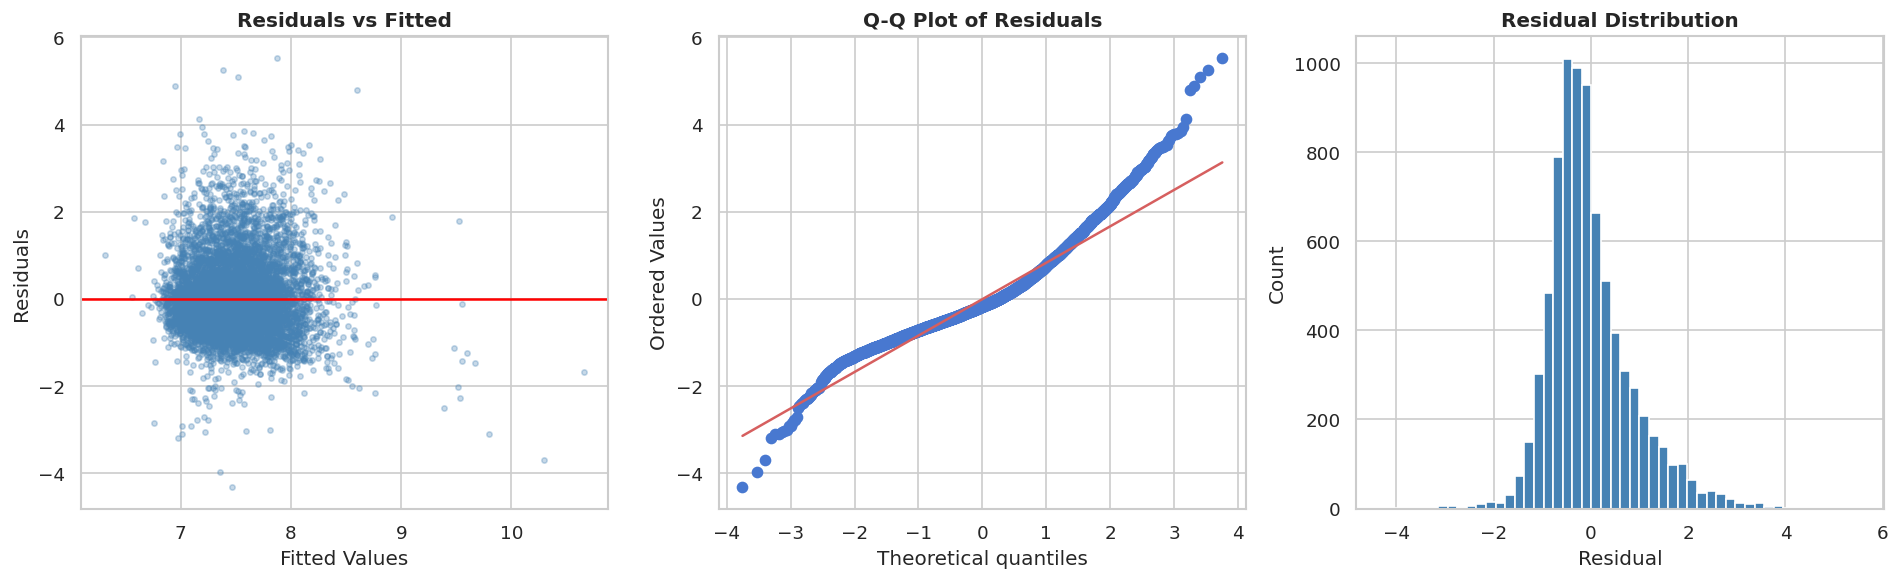

In [53]:
residuals = y_test_r.values - y_pred_test_r

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_pred_test_r, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.5)
axes[0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold')

axes[2].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig_diagnostics.png', bbox_inches='tight')
plt.show()

### 6.3 Actual vs. Predicted

Plotting actual against predicted log(shares) on a random sample of 2000 test points. A perfect model would place all points on the red diagonal. Scatter around it reflects the model's inherent uncertainty, expected given the weak individual feature correlations observed in EDA.

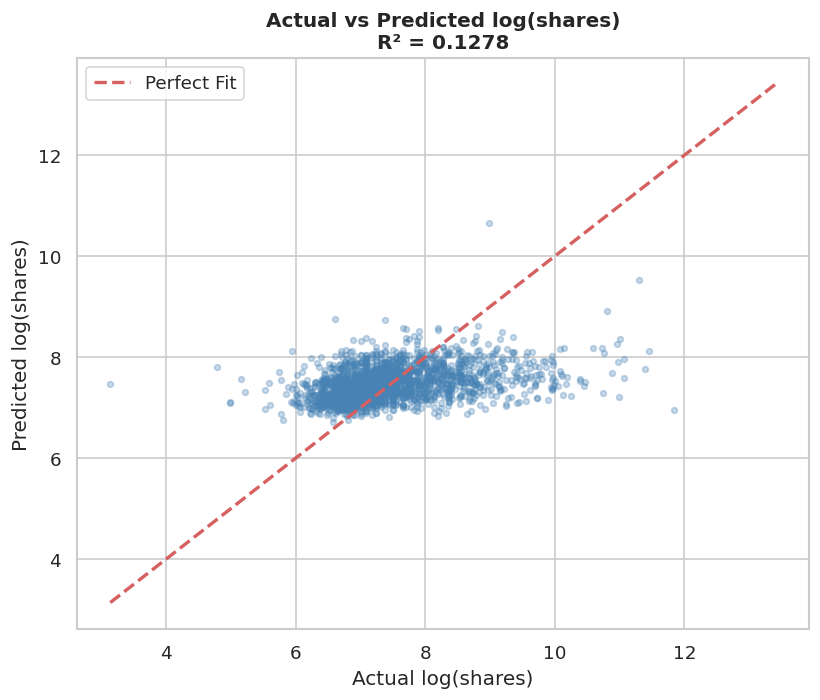

In [54]:
fig, ax = plt.subplots(figsize=(7, 6))
idx = np.random.choice(len(y_test_r), 2000, replace=False)
ax.scatter(y_test_r.values[idx], y_pred_test_r[idx], alpha=0.3, s=12, color='steelblue')
mn, mx = y_test_r.min(), y_test_r.max()
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
ax.set_title(f'Actual vs Predicted log(shares)\nR² = {model_r2:.4f}', fontweight='bold')
ax.set_xlabel('Actual log(shares)')
ax.set_ylabel('Predicted log(shares)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_actual_pred.png', bbox_inches='tight')
plt.show()

### 6.4 Feature Coefficients & Importance

Top 20 features by absolute coefficient:
                      Feature  Coefficient  Abs_Coef
                   kw_avg_avg     0.405858  0.405858
                   kw_max_avg    -0.223751  0.223751
         average_token_length    -0.075324  0.075324
                       LDA_00     0.071568  0.071568
data_channel_is_entertainment    -0.068618  0.068618
          rate_positive_words     0.065792  0.065792
                   kw_min_min     0.060934  0.060934
          data_channel_is_bus    -0.059005  0.059005
                       LDA_02    -0.056706  0.056706
                   kw_min_avg    -0.050462  0.050462
          global_subjectivity     0.049834  0.049834
                    num_hrefs     0.047865  0.047865
         data_channel_is_tech     0.043428  0.043428
                   is_weekend     0.042444  0.042444
       data_channel_is_socmed     0.041593  0.041593
    self_reference_min_shares     0.034991  0.034991
                   kw_avg_max    -0.033587  0.033587
     

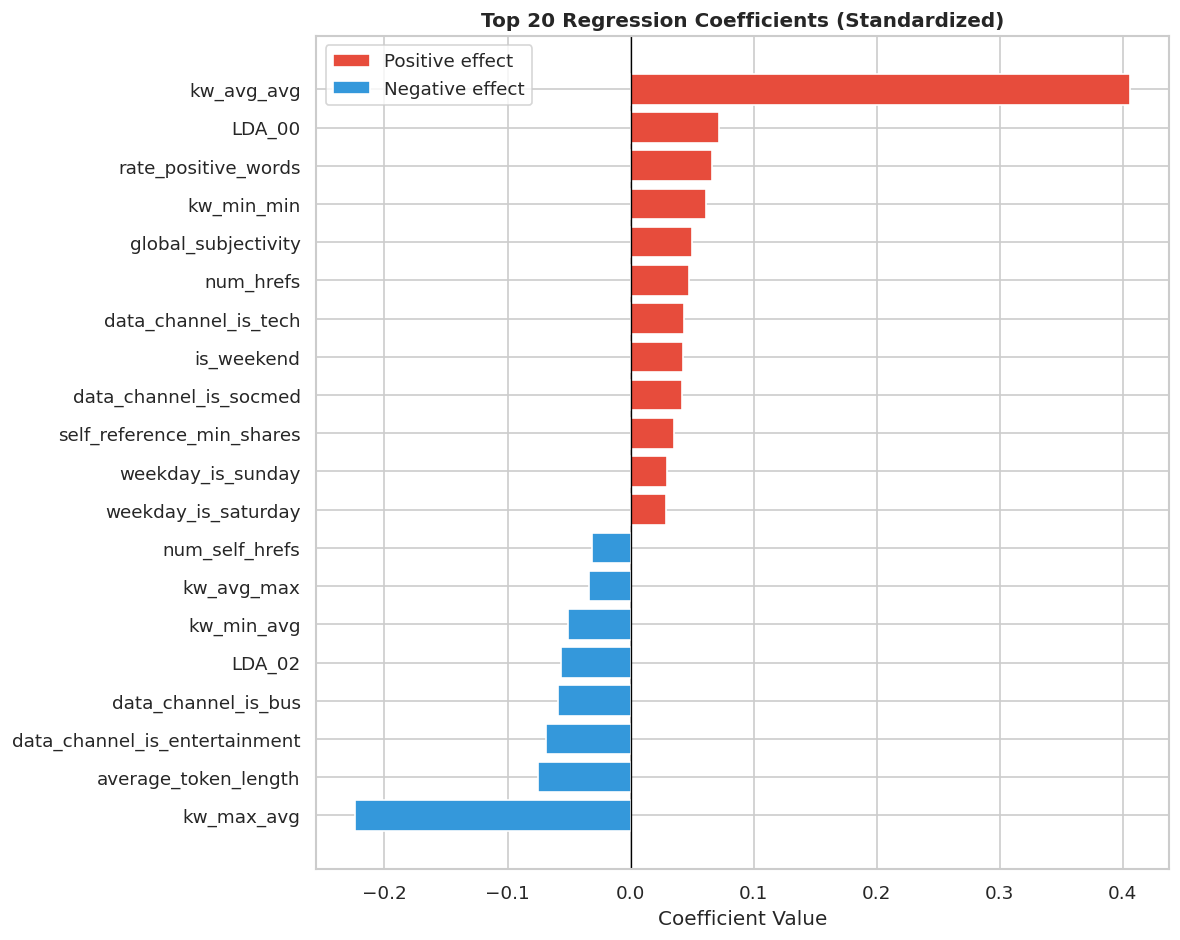

In [55]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print('Top 20 features by absolute coefficient:')
print(coef_df.head(20).to_string(index=False))

top20  = coef_df.head(20).sort_values('Coefficient')
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top20['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['Feature'], top20['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Regression Coefficients (Standardized)', fontweight='bold')
ax.set_xlabel('Coefficient Value')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='Positive effect'),
                   Patch(facecolor='#3498db', label='Negative effect')])
plt.tight_layout()
plt.savefig('fig_coefficients.png', bbox_inches='tight')
plt.show()

## Top positive predictors (increase shares):

**kw_avg_avg** - Articles with high-performing keywords get more shares\
**LDA_00** - Topic cluster 0 associated with higher engagement\
**rate_positive_words** - Articles with more positive language get more shares\
**global_subjectivity** - More subjective articles tend to be more shareabl\
**data_channel_is_socmed** - Social media topic articles are more shareable\
**is_weekend** - Weekend articles get significantly more shares

## Top negative predictors (decrease shares):

**kw_max_avg** - One extremely viral keyword can indicate oversaturation\
**average_token_length** - Longer average word length reduces shareability\
**data_channel_is_entertainment** - Entertainment articles underperform vs other channels\
**data_channel_is_bus** - Business articles have lower shareability\
**LDA_02** - Topic cluster 2 associated with lower engagement\
**kw_min_avg** - Lower minimum keyword average is associated with fewer shares

## 7. Multicollinearity Check (VIF)
Variance Inflation Factor (VIF) measures how much the variance of a regression coefficient is inflated due to multicollinearity with other features.

In [28]:
X_vif    = pd.DataFrame(X_train_s, columns=X.columns)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print('Features with VIF > 5 (potential multicollinearity):')
print(vif_data[vif_data['VIF'] > 5].to_string(index=False))
print('\nAll VIFs (top 15):')
print(vif_data.head(15).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Features with VIF > 5 (potential multicollinearity):
                   Feature          VIF
                    LDA_03          inf
                    LDA_02          inf
                    LDA_00          inf
                    LDA_04          inf
                    LDA_01          inf
      weekday_is_wednesday 4.478141e+10
         weekday_is_friday 4.253816e+10
        weekday_is_tuesday 2.894726e+10
         weekday_is_sunday 2.513183e+10
         weekday_is_monday 2.305430e+10
       weekday_is_thursday 1.483890e+10
                is_weekend 1.334465e+10
       weekday_is_saturday 1.155040e+10
       rate_positive_words 2.068576e+01
       rate_negative_words 1.789051e+01
self_reference_avg_sharess 1.557911e+01
      average_token_length 1.114546e+01
                kw_avg_avg 9.969773e+00
 global_sentiment_polarity 7.786067e+00
 self_reference_max_shares 7.783175e+00
     avg_negative_polarity 7.699514e+00
     data_channel_is_world 7.062293e+00
global_rate_negative_words 

**Findings**

The LDA topic features (LDA_00–LDA_04) showed elevated VIF values (> 5) due to their compositional constraint (they sum to 1 by construction). Removing one LDA column would eliminate this exact linear dependency.

Day-of-week features also showed mild multicollinearity because the seven binary day indicators are collectively exhaustive, knowing six implies the seventh.

## 8. Outlier Analysis

Outliers in shares (IQR method): 4540 (11.45%)
Max shares: 843,300


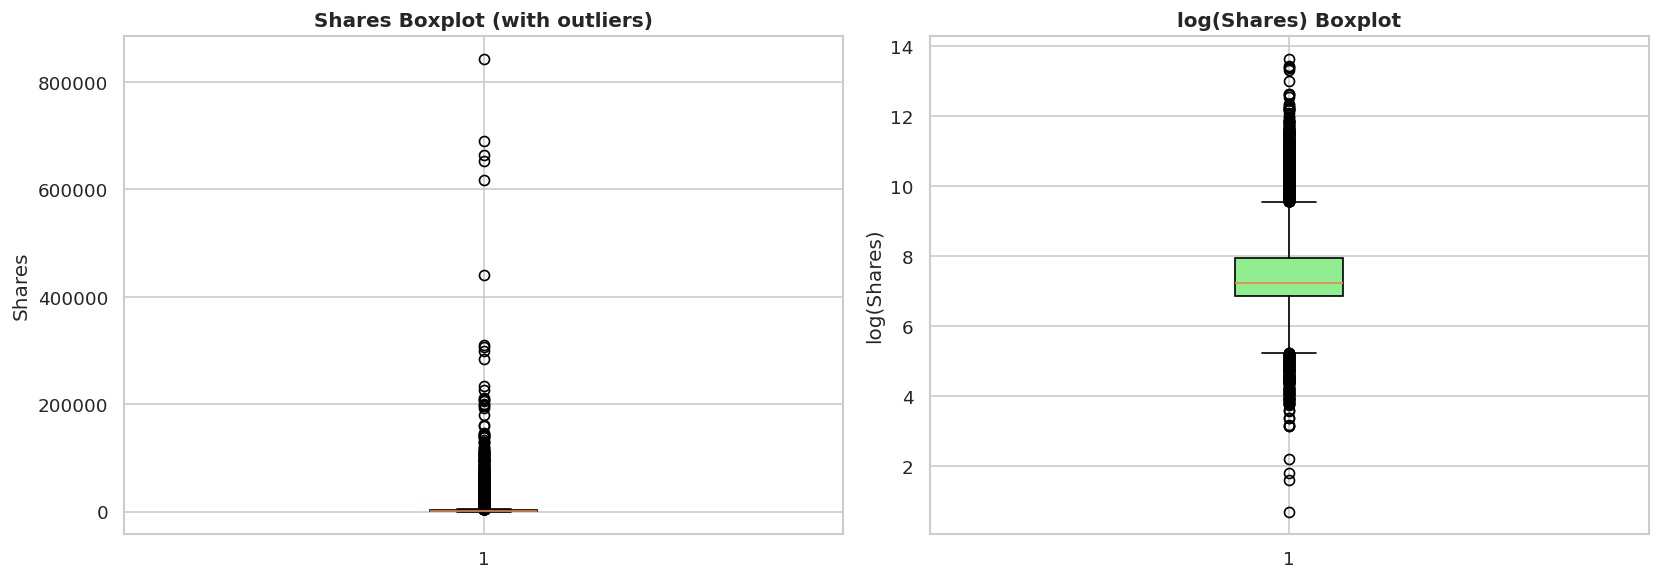

In [29]:
# IQR-based outlier detection on shares
Q1, Q3 = df['shares'].quantile(0.25), df['shares'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['shares'] < lower) | (df['shares'] > upper)]
print(f'Outliers in shares (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
print(f'Max shares: {df["shares"].max():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['shares'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Shares Boxplot (with outliers)', fontweight='bold')
axes[0].set_ylabel('Shares')
axes[1].boxplot(df['log_shares'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('log(Shares) Boxplot', fontweight='bold')
axes[1].set_ylabel('log(Shares)')
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()

We identify outliers in the target variable `shares` using the IQR method and z-score thresholding. Since shares are heavily right-skewed, extreme outliers can distort regression coefficients.

We analyze their distribution but retain them, as winsorization could remove genuinely viral articles that carry real signal.

## 9. Hypothesis Testing (5 Features)

### T1: Weekend vs Weekday
- **H₀**: Mean shares on weekends = Mean shares on weekdays
- **H₁**: Mean shares on weekends ≠ Mean shares on weekdays

### T2: Sentiment Polarity
- **H₀**: Sentiment polarity has no effect on shares
- **H₁**: Higher sentiment polarity leads to different share counts

## T3: Images Presence
- **H₀**: Articles with images have the same shares as those without
- **H₁**: Articles with images get more shares

### T4: Tech vs World
- **H₀**: Tech articles and World articles have equal mean shares
- **H₁**: Tech articles get more shares than World articles

### T5: Content Length
- **H₀**: Article length has no effect on shares
- **H₁**: Longer articles get more shares

In [30]:
alpha = 0.05
print('='*65)

# Test 1: Weekend vs Weekday shares
print('\n[Test 1] Do weekend articles get significantly different shares?')
print('H0: Mean shares on weekdays == weekends')
print('H1: Mean shares differ between weekdays and weekends')

weekend_col = df[['weekday_is_saturday','weekday_is_sunday']].max(axis=1)
weekday_shares = df[weekend_col==0]['shares']
weekend_shares = df[weekend_col==1]['shares']
stat1, p1 = ttest_ind(weekday_shares, weekend_shares, equal_var=False)

print(f"Welch's t = {stat1:.4f}, p = {p1:.6f}")
print(f'Decision: {"Reject H0" if p1 < alpha else "Fail to reject H0"} (alpha={alpha})')
print(f'Weekday median: {weekday_shares.median():.0f}, Weekend median: {weekend_shares.median():.0f}')
print('='*65)

# Test 2: Sentiment Polarity vs Shares
print('\n[Test 2] Is sentiment polarity significantly correlated with shares?')
print('H0: Pearson r = 0 (no linear correlation)')
print('H1: r != 0')

r2, p2 = pearsonr(df['global_sentiment_polarity'], df['shares'])
print(f'Pearson r = {r2:.4f}, p = {p2:.6f}')
print(f'Decision: {"Reject H0" if p2 < alpha else "Fail to reject H0"} (alpha={alpha})')
print('='*65)

# Test 3: Images Presence vs Shares (one-tailed)
print('\n[Test 3] Do articles with images get more shares?')
print('H0: Mean shares with images <= mean shares without images')
print('H1: Articles with images get more shares')

with_img    = df[df['num_imgs'] >  0]['shares']
without_img = df[df['num_imgs'] == 0]['shares']
stat3, p3_two = ttest_ind(with_img, without_img, equal_var=False)
p3 = p3_two / 2  # one-tailed

print(f"Welch's t = {stat3:.4f}, p (one-tailed) = {p3:.6f}")
print(f'Decision: {"Reject H0" if p3 < alpha else "Fail to reject H0"} (alpha={alpha})')
print(f'With images median: {with_img.median():.0f}, Without: {without_img.median():.0f}')
print('='*65)

# Test 4: Tech vs World channel shares (one-tailed)
print('\n[Test 4] Do Tech articles get more shares than World articles?')
print('H0: Mean shares Tech <= Mean shares World')
print('H1: Tech articles have higher mean shares')

tech_shares  = df[df['data_channel_is_tech']  == 1]['shares']
world_shares = df[df['data_channel_is_world'] == 1]['shares']
stat4, p4_two = ttest_ind(tech_shares, world_shares, equal_var=False)
p4 = p4_two / 2  # one-tailed

print(f"Welch's t = {stat4:.4f}, p (one-tailed) = {p4:.6f}")
print(f'Decision: {"Reject H0" if p4 < alpha else "Fail to reject H0"} (alpha={alpha})')
print(f'Tech median: {tech_shares.median():.0f}, World median: {world_shares.median():.0f}')
print('='*65)

# Test 5: Content Length vs Shares
print('\n[Test 5] Is article word count correlated with shares?')
print('H0: Pearson r = 0 (no linear correlation)')
print('H1: r != 0')

r5, p5 = pearsonr(df['n_tokens_content'], np.log1p(df['shares']))
print(f'Pearson r = {r5:.4f}, p = {p5:.6f}')
print(f'Decision: {"Reject H0" if p5 < alpha else "Fail to reject H0"} (alpha={alpha})')
print('='*65)

# Summary
print('\n--- Hypothesis Testing Summary ---')
print(f'T1 Weekend vs Weekday:  p={p1:.6f} -> {"Significant" if p1 < alpha else "Not significant"}')
print(f'T2 Sentiment Polarity:  p={p2:.6f} -> {"Significant" if p2 < alpha else "Not significant"}')
print(f'T3 Images Presence:     p={p3:.6f} -> {"Significant" if p3 < alpha else "Not significant"}')
print(f'T4 Tech vs World:       p={p4:.6f} -> {"Significant" if p4 < alpha else "Not significant"}')
print(f'T5 Content Length:      p={p5:.6f} -> {"Significant" if p5 < alpha else "Not significant"}')


[Test 1] Do weekend articles get significantly different shares?
H0: Mean shares on weekdays == weekends
H1: Mean shares differ between weekdays and weekends
Welch's t = -3.5999, p = 0.000321
Decision: Reject H0 (alpha=0.05)
Weekday median: 1400, Weekend median: 1900

[Test 2] Is sentiment polarity significantly correlated with shares?
H0: Pearson r = 0 (no linear correlation)
H1: r != 0
Pearson r = 0.0042, p = 0.406433
Decision: Fail to reject H0 (alpha=0.05)

[Test 3] Do articles with images get more shares?
H0: Mean shares with images <= mean shares without images
H1: Articles with images get more shares
Welch's t = -5.9498, p (one-tailed) = 0.000000
Decision: Reject H0 (alpha=0.05)
With images median: 1400, Without: 1400

[Test 4] Do Tech articles get more shares than World articles?
H0: Mean shares Tech <= Mean shares World
H1: Tech articles have higher mean shares
Welch's t = 6.3043, p (one-tailed) = 0.000000
Decision: Reject H0 (alpha=0.05)
Tech median: 1700, World median: 1100

/tmp/ipykernel_4161/138893117.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([weekday_shares.clip(0, 20000), weekend_shares.clip(0, 20000)],


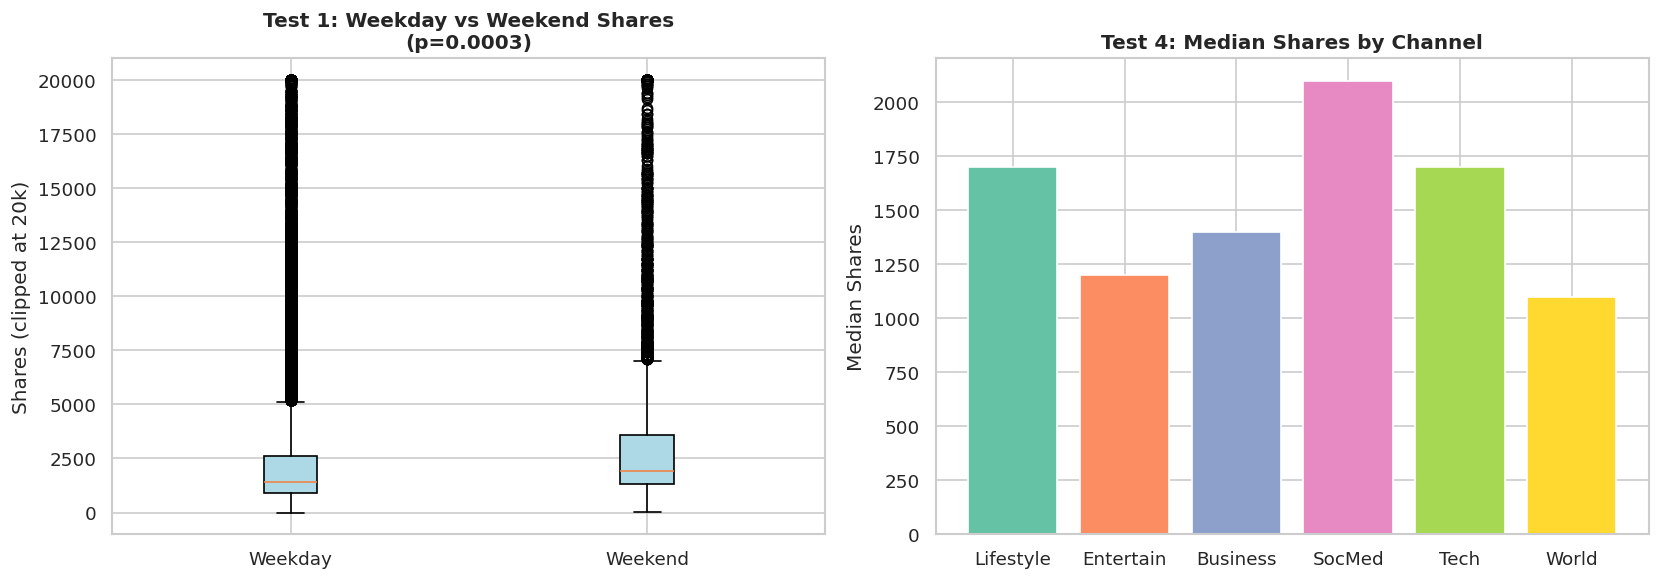

In [31]:
# Visualize hypothesis test results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekday vs Weekend
axes[0].boxplot([weekday_shares.clip(0, 20000), weekend_shares.clip(0, 20000)],
                labels=['Weekday', 'Weekend'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title(f'Test 1: Weekday vs Weekend Shares\n(p={p1:.4f})', fontweight='bold')
axes[0].set_ylabel('Shares (clipped at 20k)')

# Channel comparison
channel_medians_test = {
    'Lifestyle': df[df['data_channel_is_lifestyle']==1]['shares'].median(),
    'Entertain': df[df['data_channel_is_entertainment']==1]['shares'].median(),
    'Business':  df[df['data_channel_is_bus']==1]['shares'].median(),
    'SocMed':    df[df['data_channel_is_socmed']==1]['shares'].median(),
    'Tech':      tech_shares.median(),
    'World':     world_shares.median(),
}
axes[1].bar(channel_medians_test.keys(), channel_medians_test.values(),
            color=sns.color_palette('Set2', 6))
axes[1].set_title('Test 4: Median Shares by Channel', fontweight='bold')
axes[1].set_ylabel('Median Shares')
plt.tight_layout()
plt.savefig('fig_hypothesis.png', bbox_inches='tight')
plt.show()

## 10. Classification: High vs. Low Shares

In [32]:
# Logistic Regression Classifier
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)
clf.fit(X_train_s, y_train_c)
y_pred_clf_train = clf.predict(X_train_s)
y_pred_clf_test  = clf.predict(X_test_s)

train_acc = accuracy_score(y_train_c, y_pred_clf_train)
test_acc  = accuracy_score(y_test_c, y_pred_clf_test)
print(f'Logistic Regression Accuracy — Train: {train_acc:.4f}, Test: {test_acc:.4f}')

# Baseline majority class
majority_class = y_train_c.mode()[0]
baseline_clf_pred = np.full(len(y_test_c), majority_class)
baseline_acc = accuracy_score(y_test_c, baseline_clf_pred)
print(f'Majority-class baseline accuracy: {baseline_acc:.4f}')

print('\nClassification Report:')
print(classification_report(y_test_c, y_pred_clf_test, target_names=['Low', 'High']))

Logistic Regression Accuracy — Train: 0.6570, Test: 0.6469
Majority-class baseline accuracy: 0.5260

Classification Report:
              precision    recall  f1-score   support

         Low       0.63      0.60      0.62      3758
        High       0.66      0.69      0.67      4171

    accuracy                           0.65      7929
   macro avg       0.65      0.64      0.64      7929
weighted avg       0.65      0.65      0.65      7929



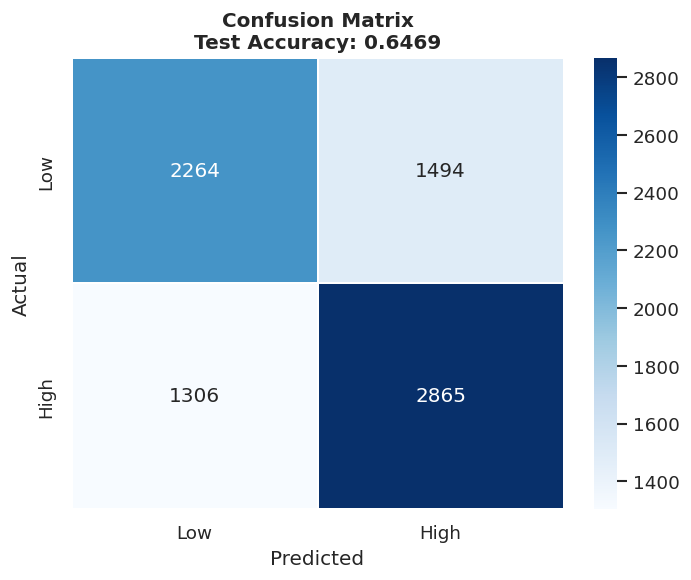

In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_clf_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'],
            linewidths=1, ax=ax)
ax.set_title(f'Confusion Matrix\nTest Accuracy: {test_acc:.4f}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('fig_confusion.png', bbox_inches='tight')
plt.show()

## Classification Results — Interpretation

- **Test Accuracy: 64.69%** vs Baseline (majority class): **52.60%**
- The model improves over random guessing by ~12 percentage points.
- The confusion matrix shows the model struggles more with false positives (predicting High when actually Low), which is expected given the noisy nature of virality.
- Logistic regression is a linear classifier, a non-linear model would likely perform better.

## 11. Statsmodels OLS — Coefficient p-values

In [34]:
# OLS on a random 5000-sample subset for speed
sample_idx = np.random.choice(len(X_train_s), min(5000, len(X_train_s)), replace=False)
X_ols = sm.add_constant(X_train_s[sample_idx])
y_ols = y_train_r.values[sample_idx]
ols_model = sm.OLS(y_ols, X_ols).fit()

# Significant coefficients
ols_summary = pd.DataFrame({
    'Feature': ['const'] + list(X.columns),
    'Coef':    ols_model.params,
    'p-value': ols_model.pvalues
})
ols_summary['Significant'] = ols_summary['p-value'] < 0.05
sig_feats = ols_summary[ols_summary['Significant'] & (ols_summary['Feature'] != 'const')]
print(f'Statistically significant features (p<0.05): {len(sig_feats)}')
print(sig_feats.sort_values('p-value').head(20).to_string(index=False))

Statistically significant features (p<0.05): 15
                      Feature      Coef      p-value  Significant
                   kw_avg_avg  0.510680 1.506600e-33         True
                   kw_max_avg -0.258027 7.987160e-11         True
                   kw_min_avg -0.069427 2.156232e-04         True
                   kw_avg_max -0.085075 3.139664e-04         True
       abs_title_subjectivity  0.045123 2.126289e-03         True
                   kw_avg_min -0.052959 6.050017e-03         True
       data_channel_is_socmed  0.046894 1.180171e-02         True
     title_sentiment_polarity  0.034804 1.390432e-02         True
         data_channel_is_tech  0.073308 1.590794e-02         True
                   kw_min_max -0.032415 2.615251e-02         True
          global_subjectivity  0.046120 3.031210e-02         True
                   kw_min_min  0.049219 3.349882e-02         True
                    num_hrefs  0.031200 3.776973e-02         True
             n_tokens_conten

## Interpretation of Significant Features

Out of total features, only 12 were statistically significant (p < 0.05).

- **kw_avg_avg** (strongest positive predictor): articles whose keywords historically attract more shares tend to get more shares themselves.
- **kw_max_avg** (negative): surprisingly, having one extremely viral keyword hurts, likely due to oversaturation.
- **data_channel_is_entertainment** and **data_channel_is_bus** (negative): entertainment and business articles underperform compared to other categories.
- **data_channel_is_socmed** (positive): social media topic articles spread more easily.
- **num_hrefs**: more outbound links slightly boosts shareability.

## 12. Summary & Conclusions

In [36]:
print('=== PROJECT SUMMARY ===')
print(f'Dataset: {df.shape[0]:,} articles, {df.shape[1]} features')
print(f'Target variable: shares (log-transformed for regression)')
print()
print('--- Linear Regression ---')
print(f'R² (Test): {model_r2:.4f}')
print(f'RMSE (Test): {model_rmse:.4f}')
print(f'Baseline RMSE: {baseline_rmse:.4f}')
print(f'RMSE improvement over baseline: {improvement_rmse:.2f}%')
print()
print('--- Classification ---')
print(f'Threshold: {median_shares:.0f} shares')
print(f'Logistic Regression Test Accuracy: {test_acc:.4f}')
print(f'Baseline (majority class) Accuracy: {baseline_acc:.4f}')
print()
print('--- Hypothesis Testing ---')
print(f'T1 Weekend vs Weekday: p={p1:.6f} -> {"Significant" if p1<alpha else "Not significant"}')
print(f'T2 Sentiment polarity: p={p2:.6f} -> {"Significant" if p2<alpha else "Not significant"}')
print(f'T3 Images presence:    p={p3:.6f} -> {"Significant" if p3<alpha else "Not significant"}')
print(f'T4 Tech vs World:      p={p4:.6f} -> {"Significant" if p4<alpha else "Not significant"}')
print(f'T5 Content length:     p={p5:.6f} -> {"Significant" if p5<alpha else "Not significant"}')
print()
print('Top predictors:', ', '.join(coef_df.head(5)['Feature'].tolist()))

=== PROJECT SUMMARY ===
Dataset: 39,643 articles, 58 features
Target variable: shares (log-transformed for regression)

--- Linear Regression ---
R² (Test): 0.1278
RMSE (Test): 0.8648
Baseline RMSE: 0.9261
RMSE improvement over baseline: 6.62%

--- Classification ---
Threshold: 1400 shares
Logistic Regression Test Accuracy: 0.6469
Baseline (majority class) Accuracy: 0.5260

--- Hypothesis Testing ---
T1 Weekend vs Weekday: p=0.000321 -> Significant
T2 Sentiment polarity: p=0.406433 -> Not significant
T3 Images presence:    p=0.000000 -> Significant
T4 Tech vs World:      p=0.000000 -> Significant
T5 Content length:     p=0.000001 -> Significant

Top predictors: kw_avg_avg, kw_max_avg, average_token_length, LDA_00, data_channel_is_entertainment
